<a href="https://colab.research.google.com/github/RoihansLab/Machine-Learning-Projects/blob/main/Praktikum_Matkul/Minggu_2_Linear_Regression_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Implimentation Linear Regression

In [91]:
#1. Import Library
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [92]:
# 2 Agar Hasil angka acak selalu sama
np.random.seed(42)

# 3. Membuat 50 data inpiut X
# Nilai X berada antara 0 sampai 100
X = np.random.rand(100, 1)* 100

# 4. Membuat target Y
# hubungan dasar: Y = 3.5X
# kemudian di tambahkan noise agar lebih mirip data nyata
y = 3.5 * X + np.random.randn(100, 1) * 20

In [93]:
model  = LinearRegression()
model.fit(X, y)
Y_pred = model.predict(X)

In [94]:
print("slope :", model.coef_[0][0])
print("Intercept :", model.intercept_[0])

slope : 3.4080453545753935
Intercept : 4.301923150934982


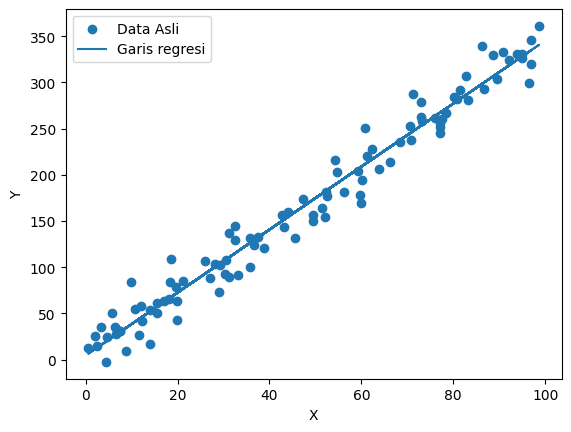

In [95]:
plt.scatter(X, y, label="Data Asli")
plt.plot(X, Y_pred, label="Garis regresi")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [96]:
r2 = model.score(X, y)
print("R-squared:", r2)

R-squared: 0.9692697833613652


# 2. Multiple Linear Regression

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

In [98]:
df = fetch_california_housing()

X = pd.DataFrame(df.data, columns=df.feature_names)
Y = pd.Series(df.target)

In [99]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [100]:
X = X[['MedInc', 'AveRooms']]

In [101]:
X

,MedInc,AveRooms
0,8.3252,6.984127
1,8.3014,6.238137
2,7.2574,8.288136
3,5.6431,5.817352
4,3.8462,6.281853
...,...,...
20635,1.5603,5.045455
20636,2.5568,6.114035
20637,1.7000,5.205543
20638,1.8672,5.329513


In [102]:
y

array([[132.82998296],
       [326.76986023],
       [258.03309516],
       [169.77909118],
       [ 50.2130864 ],
       [ 61.74033355],
       [ 49.88714515],
       [292.79624666],
       [194.22038205],
       [237.79026136],
       [ 25.51261536],
       [346.04347045],
       [280.7597202 ],
       [ 84.5840374 ],
       [ 65.58028951],
       [ 83.56447826],
       [ 92.44372316],
       [177.11150814],
       [143.33859346],
       [ 72.65990011],
       [220.07091869],
       [ 54.04395667],
       [102.35289612],
       [123.53490249],
       [131.31707963],
       [266.39868003],
       [ 63.03153342],
       [163.93650806],
       [204.11938487],
       [ 24.33866159],
       [250.36441619],
       [ 63.17499955],
       [ 27.91906536],
       [330.62101972],
       [299.59578727],
       [282.40879433],
       [107.81942341],
       [ 83.45008215],
       [235.63433998],
       [160.08431966],
       [ 42.0191468 ],
       [149.93835779],
       [ 34.89243868],
       [333

In [103]:
X_train, X_test , Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [104]:
model = LinearRegression()

model.fit(X, Y)

LinearRegression()

In [105]:
print('Intercept:', model.intercept_)
print("Slope:", model.coef_)

Intercept: 0.5949584738121918
Slope: [ 0.43416302 -0.03811061]


In [106]:
y_pred = model.predict(X_test)

In [107]:
r2_test = model.score(X_test, Y_test)
print("R-squared (test):", r2_test)

R-squared (test): 0.46436640105846194


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


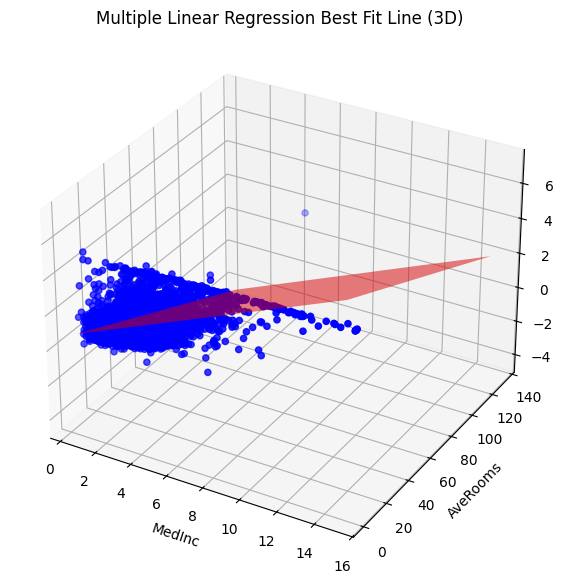

In [108]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test['MedInc'], X_test['AveRooms'],
           Y_test , color='blue', label='Actual Data')

x1_range = np.linspace(X_test['MedInc'].min(), X_test['MedInc'].max(), 100)
x2_range = np.linspace(X_test['AveRooms'].min(), X_test['AveRooms'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)


# Perbaikan di baris z:
z = model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)
ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('MedInc')
ax.set_ylabel('AveRooms')
ax.set_zlabel('House Price')
ax.set_title('Multiple Linear Regression Best Fit Line (3D)')

plt.show()

In [109]:
X1 = pd.DataFrame(df.data, columns=df.feature_names)
y1 = pd.Series(df.target)

In [110]:
X1 = X1[['MedInc', 'AveRooms', 'HouseAge']]
X1

,MedInc,AveRooms,HouseAge
0,8.3252,6.984127,41.0
1,8.3014,6.238137,21.0
2,7.2574,8.288136,52.0
3,5.6431,5.817352,52.0
4,3.8462,6.281853,52.0
...,...,...,...
20635,1.5603,5.045455,25.0
20636,2.5568,6.114035,18.0
20637,1.7000,5.205543,17.0
20638,1.8672,5.329513,18.0


In [111]:
y1

,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [112]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [113]:
model1 = LinearRegression()
model1.fit(X_train1, y_train1)

LinearRegression()

In [114]:
print('Intercept:', model.intercept_)
print("Slope:", model.coef_)

Intercept: 0.5949584738121918
Slope: [ 0.43416302 -0.03811061]


In [115]:
y_pred = model1.predict(X_test1)

In [117]:
r2_test = model1.score(X_test1, y_test1)
print("R-squared (test):", r2_test)

R-squared (test): 0.49717158850807075


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


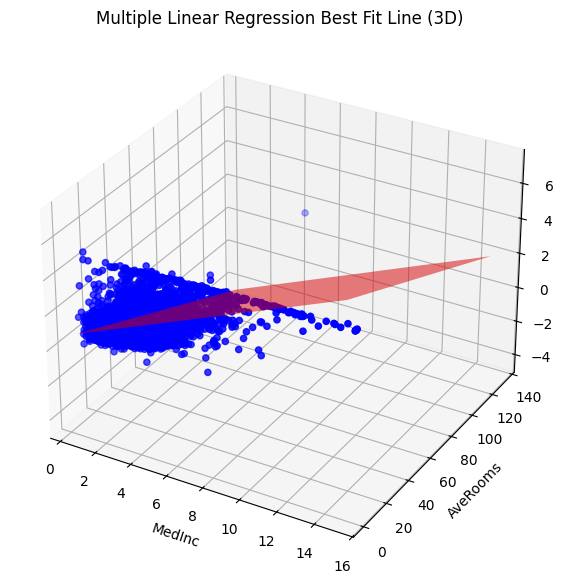

In [118]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test1['MedInc'], X_test1['AveRooms'],
           y_test1 , color='blue', label='Actual Data')

x1_range = np.linspace(X_test1['MedInc'].min(), X_test1['MedInc'].max(), 100)
x2_range = np.linspace(X_test1['AveRooms'].min(), X_test1['AveRooms'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)


# Perbaikan di baris z:
z = model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)
ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('MedInc')
ax.set_ylabel('AveRooms')
ax.set_zlabel('House Price')
ax.set_title('Multiple Linear Regression Best Fit Line (3D)')

plt.show()